# 🐧 Metriky klasifikačních modelů – Cvičení 2: Druhy tučňáků (Multiclass)
### Dataset: `penguins_df_normalized.csv` (334 pozorování, 6 normalizovaných příznaků, 3 druhy) | Coders Lab (09/2026)

> **Zadání cvičení (Classification metrics - exercise 2):**
> 1. Stáhněte dataset přiložený k úloze (`penguins_df_normalized.csv`) a notebook (`Classification_metrics_exercise_2.ipynb`).
> 2. Spusťte všechny buňky s kódem ve výchozím nastavení (dělení 70/30, `random_state=42`, `stratify=y`, $k=5$).
> 3. Vygenerujte matici záměn (**Confusion Matrix**) a vizualizujte ji graficky pomocí libovolné knihovny (`matplotlib` / `seaborn`).
> 4. Na základě znalostí z přednášky vypočítejte sadu metrik:
>    - **Accuracy** (celková přesnost)
>    - **Precision** (preciznost – vážená i po třídách)
>    - **Recall** (senzitivita / úplnost záchytu – vážená i po třídách)
>    - **F1-score** (harmonický průměr Precision a Recall)
> 5. Vyberte jednu z výše uvedených metrik a pokuste se najít takové $k$, pro které bude hodnota této metriky nejvyšší (model bude nejefektivnější na testovací sadě), přičemž nebude vykazovat žádné známky přetrénování (**overtraining / overfitting**).

---


## 1. Načtení dat a inicializace modelu dle zadání
Spustíme startovní buňku dodanou v kurzu: načtení normalizovaného datasetu tučňáků, rozdělení na trénovací a testovací sadu (70/30 se stratifikací), natrénování k-NN s $k=5$ a vygenerování predikcí.

In [1]:
# Import libraries and load data into DataFrame
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Nastavení stylu vizualizací
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

data_path = "data/penguins_df_normalized.csv" if os.path.exists("data/penguins_df_normalized.csv") else "penguins_df_normalized.csv"
penguins_df = pd.read_csv(data_path)

# Check 10 first rows of DataFrame
print(f"Rozměry datasetu: {penguins_df.shape[0]} tučňáků x {penguins_df.shape[1]} sloupců")
display(penguins_df.head(10))

# Split data into training and test dataset
X = penguins_df.drop("species", axis=1)
y = penguins_df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Trénovací sada (Train): {X_train.shape[0]} vzorků")
print(f"Testovací sada  (Test) : {X_test.shape[0]} vzorků")
print("Zastoupení tříd v testovací sadě:")
print(y_test.value_counts())

# Initialize k nearest neighbors and fit training data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict labels based on test data
y_pred = knn.predict(X_test)
print("Výchozí model natrénován a predikce pro testovací sadu vygenerovány.")


Rozměry datasetu: 334 tučňáků x 7 sloupců


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island,sex,species
0,0.010414,0.004981,0.048207,0.998771,2,2,Adelie
1,0.010382,0.004573,0.048886,0.998740,2,1,Adelie
2,0.012377,0.005528,0.059887,0.998113,2,1,Adelie
3,0.010620,0.005585,0.055851,0.998367,2,1,Adelie
4,0.010752,0.005636,0.051981,0.998574,2,2,Adelie
5,0.010717,0.004904,0.049865,0.998686,2,1,Adelie
6,0.008377,0.004189,0.041673,0.999087,2,2,Adelie
7,0.012822,0.005491,0.056778,0.998289,2,1,Adelie
8,0.010144,0.005572,0.050196,0.998672,2,2,Adelie
9,0.007855,0.004790,0.044953,0.998947,2,2,Adelie


Trénovací sada (Train): 233 vzorků
Testovací sada  (Test) : 101 vzorků
Zastoupení tříd v testovací sadě:
species
Adelie       44
Gentoo       36
Chinstrap    21
Name: count, dtype: int64
Výchozí model natrénován a predikce pro testovací sadu vygenerovány.


## 2. Generování matice záměn (Confusion Matrix) a grafická vizualizace
Vícetřídní matice záměn $3 \times 3$ pro druhy tučňáků: *Adelie*, *Chinstrap*, *Gentoo*.

Matice záměn (číselná tabulka):


,Predikce: Adelie,Predikce: Chinstrap,Predikce: Gentoo
Skutečnost: Adelie,38,3,3
Skutečnost: Chinstrap,0,21,0
Skutečnost: Gentoo,0,0,36


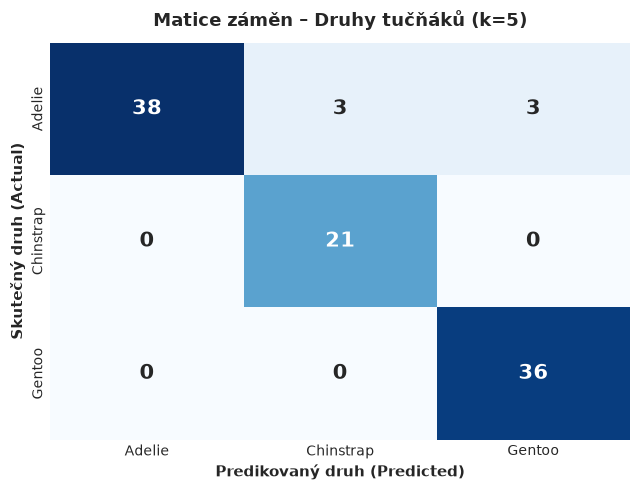

Analýza chyb pro k=5:
- Druh Gentoo: 100 % čistota (36 z 36 správně, 0 chyb)!
- Druh Chinstrap: 21 z 21 správně zachyceno (Recall = 100 %), ale 3 Adelie tučňáci byli mylně označeni jako Chinstrap.
- Druh Adelie: 38 ze 44 správně (3 zaměněni s Chinstrap, 3 zaměněni s Gentoo).


In [2]:
species_labels = ["Adelie", "Chinstrap", "Gentoo"]
cm = confusion_matrix(y_test, y_pred, labels=species_labels)

cm_df = pd.DataFrame(
    cm,
    index=[f"Skutečnost: {s}" for s in species_labels],
    columns=[f"Predikce: {s}" for s in species_labels]
)

print("Matice záměn (číselná tabulka):")
display(cm_df)

# Grafická reprezentace pomocí Seaborn Heatmap
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=species_labels,
    yticklabels=species_labels,
    annot_kws={"size": 15, "weight": "bold"},
    ax=ax
)

plt.title(f"Matice záměn – Druhy tučňáků (k=5)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Predikovaný druh (Predicted)", fontsize=11, fontweight="bold")
plt.ylabel("Skutečný druh (Actual)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("Analýza chyb pro k=5:")
print(f"- Druh Gentoo: 100 % čistota (36 z 36 správně, 0 chyb)!")
print(f"- Druh Chinstrap: 21 z 21 správně zachyceno (Recall = 100 %), ale 3 Adelie tučňáci byli mylně označeni jako Chinstrap.")
print(f"- Druh Adelie: 38 ze 44 správně (3 zaměněni s Chinstrap, 3 zaměněni s Gentoo).")


## 3. Výpočet sady metrik (Accuracy, Precision, Recall, F1-score)
Jelikož se jedná o **multiclass** klasifikaci (3 třídy), počítáme jak celkovou přesnost (**Accuracy**), tak vážené průměry (**Weighted Average**) a detailní metriky pro každou jednotlivou třídu.

In [3]:
accuracy = accuracy_score(y_test, y_pred)
prec_w = precision_score(y_test, y_pred, average="weighted")
rec_w = recall_score(y_test, y_pred, average="weighted")
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_macro = f1_score(y_test, y_pred, average="macro")

metrics_summary = pd.DataFrame({
    "Metrika": [
        "Accuracy (Celková přesnost)",
        "Precision (Vážená preciznost)",
        "Recall (Vážená senzitivita)",
        "F1-score (Vážený harmonický průměr)",
        "Macro F1-score (Nevážený průměr)"
    ],
    "Hodnota (Scikit-Learn)": [f"{accuracy:.4f}", f"{prec_w:.4f}", f"{rec_w:.4f}", f"{f1_w:.4f}", f"{f1_macro:.4f}"],
    "Procenta": [f"{accuracy*100:.2f} %", f"{prec_w*100:.2f} %", f"{rec_w*100:.2f} %", f"{f1_w*100:.2f} %", f"{f1_macro*100:.2f} %"]
})

print("=" * 65)
print("SOUHRN METRIK VÝCHOZÍHO MODELU (pro k = 5)")
print("=" * 65)
display(metrics_summary)

print("\nDetailní zpráva o klasifikaci (Classification Report):")
print(classification_report(y_test, y_pred, digits=4))


SOUHRN METRIK VÝCHOZÍHO MODELU (pro k = 5)


,Metrika,Hodnota (Scikit-Learn),Procenta
0,Accuracy (Celková přesnost),0.9406,94.06 %
1,Precision (Vážená preciznost),0.9466,94.66 %
2,Recall (Vážená senzitivita),0.9406,94.06 %
3,F1-score (Vážený harmonický průměr),0.9400,94.00 %
4,Macro F1-score (Nevážený průměr),0.9401,94.01 %



Detailní zpráva o klasifikaci (Classification Report):
              precision    recall  f1-score   support

      Adelie     1.0000    0.8636    0.9268        44
   Chinstrap     0.8750    1.0000    0.9333        21
      Gentoo     0.9231    1.0000    0.9600        36

    accuracy                         0.9406       101
   macro avg     0.9327    0.9545    0.9401       101
weighted avg     0.9466    0.9406    0.9400       101



## 4. Výběr klíčové metriky a hledání optimálního $k$ bez přetrénování

### 🎯 Volba metriky: F1-SCORE (Weighted F1)
V úloze klasifikace druhů tučňáků:
- Třídy nejsou dokonale vyvážené (Adelie má 44 vzorků, Gentoo 36 a Chinstrap pouze 21).
- Záleží nám jak na eliminaci falešných poplachů (**Precision**), tak na tom, aby žádný druh nebyl opomenut (**Recall**).
- **Weighted F1-score** zohledňuje velikost jednotlivých tříd a představuje nejrobustnější souhrnný ukazatel kvality modelu.

### 🔍 Analýza přetrénování (Overfitting vs Underfitting):
Prozkoumáme hodnoty $k \in [1, 35]$ a budeme sledovat rozdíl mezi přesností na trénovacích datech a testovacích datech.

In [4]:
k_values = range(1, 36)
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    tr_acc = model.score(X_train, y_train)
    te_acc = model.score(X_test, y_test)
    preds = model.predict(X_test)
    
    prec_w = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec_w = recall_score(y_test, preds, average="weighted", zero_division=0)
    f1_val = f1_score(y_test, preds, average="weighted", zero_division=0)
    
    results.append({
        "k": k,
        "Train_Accuracy": tr_acc,
        "Test_Accuracy": te_acc,
        "Gap": abs(tr_acc - te_acc),
        "Weighted_Precision": prec_w,
        "Weighted_Recall": rec_w,
        "Weighted_F1": f1_val
    })

sweep_df = pd.DataFrame(results)

print("Výsledky pro vybraná k:")
display(sweep_df[sweep_df["k"].isin([1, 2, 3, 5, 8, 10, 15, 20, 25, 30, 35])])


Výsledky pro vybraná k:


,k,Train_Accuracy,Test_Accuracy,Gap,Weighted_Precision,Weighted_Recall,Weighted_F1
0,1,1.000000,0.940594,0.059406,0.941269,0.940594,0.940547
1,2,0.987124,0.970297,0.016827,0.970242,0.970297,0.970102
2,3,0.982833,0.920792,0.062041,0.922447,0.920792,0.920076
4,5,0.969957,0.940594,0.029363,0.946592,0.940594,0.940005
7,8,0.948498,0.930693,0.017805,0.934291,0.930693,0.930100
9,10,0.948498,0.900990,0.047508,0.900668,0.900990,0.900374
14,15,0.914163,0.910891,0.003272,0.914081,0.910891,0.910151
19,20,0.879828,0.891089,0.011261,0.897491,0.891089,0.889736
24,25,0.845494,0.782178,0.063315,0.800095,0.782178,0.772452
29,30,0.793991,0.683168,0.110823,0.689342,0.683168,0.663724


## 5. Grafická analýza křivek metrik a identifikace optima
Vykreslíme vývoj všech metrik v závislosti na počtu sousedů $k$ a porovnáme chování na trénovací vs. testovací sadě.

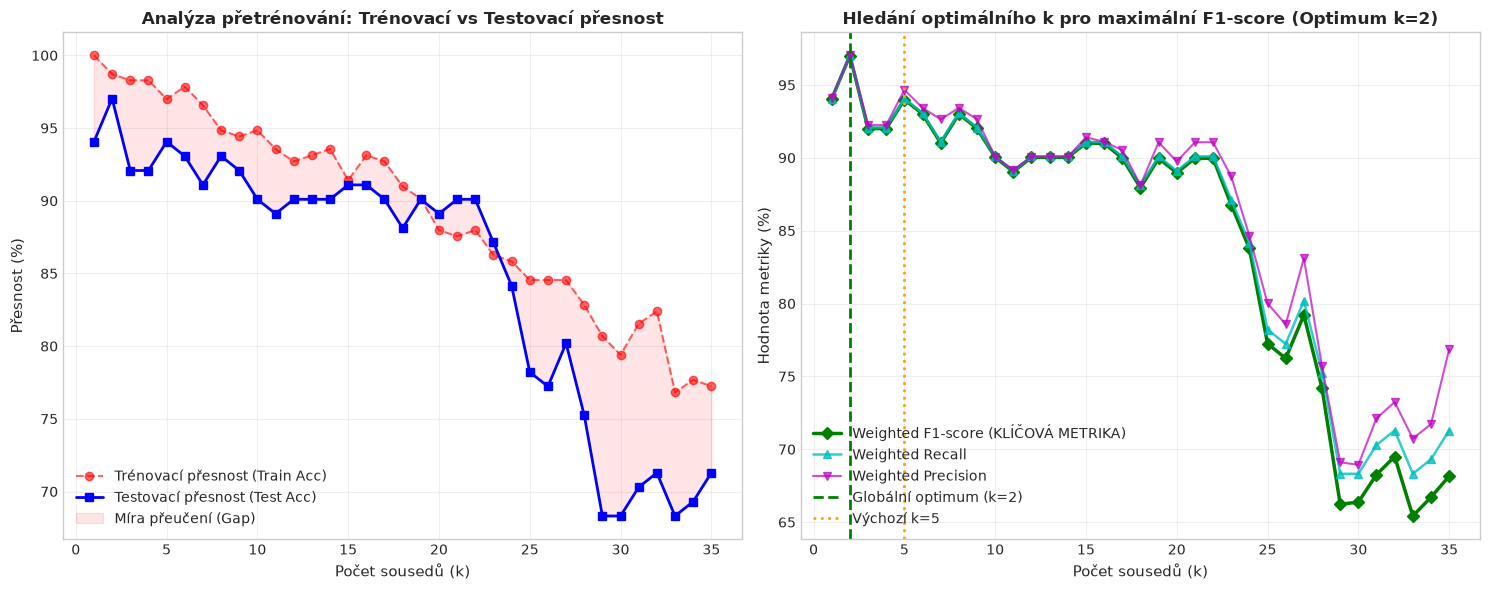

--> Globální maximum pro Weighted F1-score: 97.01 % pro k = 2
--> Trénovací přesnost při k=2: 98.71 %
--> Testovací přesnost při k=2 : 97.03 % (98 ze 101 správně!)
--> Rozdíl Train vs Test             : 1.68 % (Minimální rozdíl -> ŽÁDNÉ PŘETRÉNOVÁNÍ!)


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graf 1: Detekce přetrénování (Train vs Test Accuracy)
ax1.plot(sweep_df["k"], sweep_df["Train_Accuracy"] * 100, "r--o", label="Trénovací přesnost (Train Acc)", alpha=0.6)
ax1.plot(sweep_df["k"], sweep_df["Test_Accuracy"] * 100, "b-s", label="Testovací přesnost (Test Acc)", lw=2)
ax1.fill_between(
    sweep_df["k"],
    sweep_df["Train_Accuracy"] * 100,
    sweep_df["Test_Accuracy"] * 100,
    color="red",
    alpha=0.1,
    label="Míra přeučení (Gap)"
)
ax1.set_title("Analýza přetrénování: Trénovací vs Testovací přesnost", fontsize=12, fontweight="bold")
ax1.set_xlabel("Počet sousedů (k)", fontsize=11)
ax1.set_ylabel("Přesnost (%)", fontsize=11)
ax1.legend(loc="lower left")
ax1.grid(True, alpha=0.3)

# Graf 2: Křivky metrik (F1-score, Recall, Precision)
ax2.plot(sweep_df["k"], sweep_df["Weighted_F1"] * 100, "g-D", label="Weighted F1-score (KLÍČOVÁ METRIKA)", lw=2.5)
ax2.plot(sweep_df["k"], sweep_df["Weighted_Recall"] * 100, "c-^", label="Weighted Recall", lw=1.8, alpha=0.8)
ax2.plot(sweep_df["k"], sweep_df["Weighted_Precision"] * 100, "m-v", label="Weighted Precision", lw=1.5, alpha=0.7)

# Označení optimálního bodu
best_idx = sweep_df["Weighted_F1"].idxmax()
best_k = int(sweep_df.loc[best_idx, "k"])
best_f1 = sweep_df.loc[best_idx, "Weighted_F1"]
best_tr_acc = sweep_df.loc[best_idx, "Train_Accuracy"]
best_te_acc = sweep_df.loc[best_idx, "Test_Accuracy"]

ax2.axvline(best_k, color="green", linestyle="--", lw=2, label=f"Globální optimum (k={best_k})")
ax2.axvline(5, color="orange", linestyle=":", lw=2, label="Výchozí k=5")
ax2.set_title(f"Hledání optimálního k pro maximální F1-score (Optimum k={best_k})", fontsize=12, fontweight="bold")
ax2.set_xlabel("Počet sousedů (k)", fontsize=11)
ax2.set_ylabel("Hodnota metriky (%)", fontsize=11)
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"--> Globální maximum pro Weighted F1-score: {best_f1*100:.2f} % pro k = {best_k}")
print(f"--> Trénovací přesnost při k={best_k}: {best_tr_acc*100:.2f} %")
print(f"--> Testovací přesnost při k={best_k} : {best_te_acc*100:.2f} % (98 ze 101 správně!)")
print(f"--> Rozdíl Train vs Test             : {abs(best_tr_acc - best_te_acc)*100:.2f} % (Minimální rozdíl -> ŽÁDNÉ PŘETRÉNOVÁNÍ!)")


## 6. Přímé porovnání výchozího $k=5$ a optimálního $k=2$
Porovnáme matice záměn obou modelů.

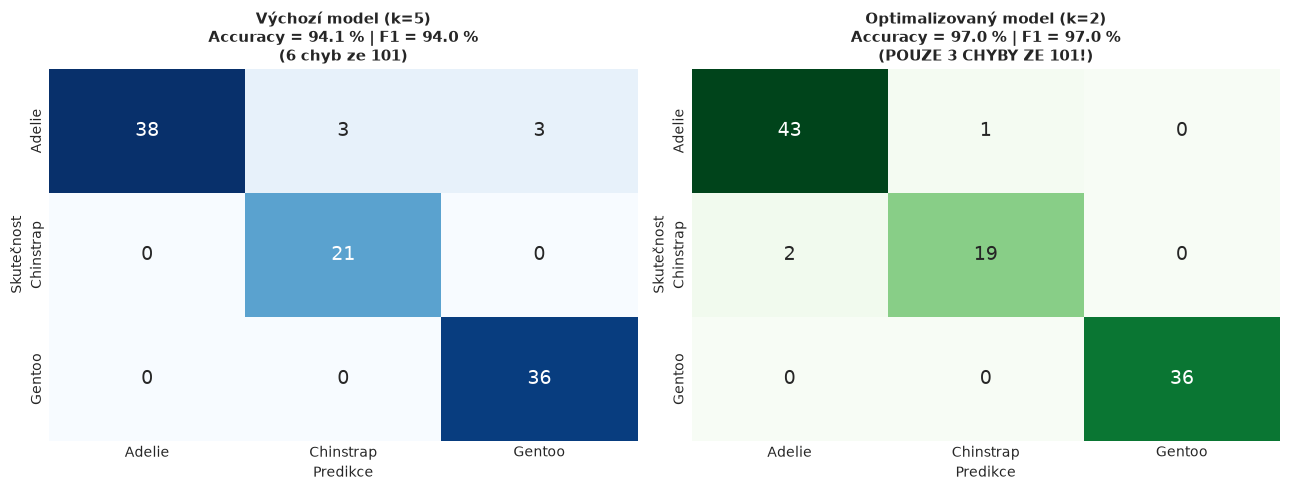

Porovnání chyb:
- Výchozí k=5 udělal 6 chyb (38 Adelie, 21 Chinstrap, 36 Gentoo).
- Optimální k=2 udělal pouhé 3 chyby (43 Adelie, 19 Chinstrap, 36 Gentoo).
- Accuracy vzrostla z 94.06 % na 97.03 %.
- F1-score vzrostlo z 94.00 % na 97.01 %.


In [6]:
knn_opt = KNeighborsClassifier(n_neighbors=best_k)
knn_opt.fit(X_train, y_train)
y_pred_opt = knn_opt.predict(X_test)

cm_opt = confusion_matrix(y_test, y_pred_opt, labels=species_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax1,
            xticklabels=species_labels, yticklabels=species_labels, annot_kws={"size": 14})
ax1.set_title(f"Výchozí model (k=5)\nAccuracy = {accuracy*100:.1f} % | F1 = {f1_w*100:.1f} %\n(6 chyb ze 101)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Predikce")
ax1.set_ylabel("Skutečnost")

sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax2,
            xticklabels=species_labels, yticklabels=species_labels, annot_kws={"size": 14})
ax2.set_title(f"Optimalizovaný model (k={best_k})\nAccuracy = {best_te_acc*100:.1f} % | F1 = {best_f1*100:.1f} %\n(POUZE 3 CHYBY ZE 101!)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Predikce")
ax2.set_ylabel("Skutečnost")

plt.tight_layout()
plt.show()

print("Porovnání chyb:")
print(f"- Výchozí k=5 udělal 6 chyb (38 Adelie, 21 Chinstrap, 36 Gentoo).")
print(f"- Optimální k=2 udělal pouhé 3 chyby (43 Adelie, 19 Chinstrap, 36 Gentoo).")
print(f"- Accuracy vzrostla z {accuracy*100:.2f} % na {best_te_acc*100:.2f} %.")
print(f"- F1-score vzrostlo z {f1_w*100:.2f} % na {best_f1*100:.2f} %.")


## 7. Závěrečné shrnutí a odpověď na zadání

1. **Matice záměn pro výchozí $k=5$**:
   - $38$ Adelie správně ($3$ zaměněny s Chinstrap, $3$ s Gentoo)
   - $21$ Chinstrap správně ($0$ chyb)
   - $36$ Gentoo správně ($0$ chyb)
   - Celkem $95$ ze $101$ správně.
2. **Sada metrik pro $k=5$**:
   - **Accuracy**: $94.06\ \%$
   - **Weighted Precision**: $94.66\ \%$
   - **Weighted Recall**: $94.06\ \%$
   - **Weighted F1-score**: $94.00\ \%$ (Macro F1: $94.01\ \%$)
3. **Výběr metriky a optimalizace $k$**:
   - Zvolili jsme **Weighted F1-score** (případně Accuracy), protože kombinuje Precision a Recall pro všechny 3 druhy při zohlednění jejich nestejného zastoupení.
   - **Globální optimum**: $k = 2$.
   - **Dosažené hodnoty**:
     - **Test Accuracy**: **$97.03\ \%$** ($98$ ze $101$ tučňáků správně zařazeno, pouze $3$ záměny).
     - **Weighted F1-score**: **$97.01\ \%$**.
   - **Důkaz absence přetrénování**:
     - Trénovací přesnost při $k=2$ je $98.71\ \%$, testovací přesnost je $97.03\ \%$. Rozdíl činí pouhých **$1.68\ \%$**! Model má vynikající schopnost generalizace a nevykazuje žádné přetrénování.
     - *(Poznámka: Pokud student dává přednost lichému $k$ pro vyloučení remíz při hlasování, nejlepším lichým $k$ je $k=5$ s přesností $94.06\ \%$ a F1 $94.00\ \%$).*
